## Monte Carlo simulation

1. 환경 설명 
     - episode당 steps 수 : 7 steps
     - state 이동 방법 : 1번부터 7번까지 순차적으로 움직임 
     - 7번까지 이동하면 episode 종료  
     - action_list = [1,2,3,4,5] 
     - num of actions = 5
     - state_line_length = [500, 550, 950, 1200, 2300, 3000, 5000]
     - target_resistance = 400
     - state_resistance = state_length/width, action을 width로 그대로 사용함     
     - 목표 : 목표 저항에 가장 가깝게 설정  
     - <font color="red">reward : 목표 저항차이를 최소화 하도록 설정</font>    

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:


# 환경 클래스
class Environment:
    def __init__(self):
        self.state_lengths = [500, 550, 950, 1200, 2300, 3000, 5000]
        self.target_resistance = 400
        self.step_count = 0

    def reset(self):
        self.step_count = 0
        return self.step_count
    
    def step(self, action):
        state_length = self.state_lengths[self.step_count]
        state_resistance = state_length / action
        self.step_count += 1

        done = self.step_count >= len(self.state_lengths)
        
        reward =  -abs(state_resistance - self.target_resistance) # 차이가 작을 수록 좋으므로 음수로 계산
        
        return self.step_count, reward, done, {}   

## Agent 및 train 설정

Episode 5000/100000 - Avg Reward: -194.29
Episode 10000/100000 - Avg Reward: -247.86
Episode 15000/100000 - Avg Reward: -230.95
Episode 20000/100000 - Avg Reward: -244.05
Episode 25000/100000 - Avg Reward: -631.55
Episode 30000/100000 - Avg Reward: -284.76
Episode 35000/100000 - Avg Reward: -212.14
Episode 40000/100000 - Avg Reward: -217.14
Episode 45000/100000 - Avg Reward: -241.07
Episode 50000/100000 - Avg Reward: -233.57
Episode 55000/100000 - Avg Reward: -316.31
Episode 60000/100000 - Avg Reward: -489.29
Episode 65000/100000 - Avg Reward: -294.64
Episode 70000/100000 - Avg Reward: -177.62
Episode 75000/100000 - Avg Reward: -232.38
Episode 80000/100000 - Avg Reward: -189.76
Episode 85000/100000 - Avg Reward: -190.71
Episode 90000/100000 - Avg Reward: -192.50
Episode 95000/100000 - Avg Reward: -303.57
Episode 100000/100000 - Avg Reward: -270.48

=== Episode 1 ===
Step 1: State=0, Action=2, Resistance=250.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=3, Resi

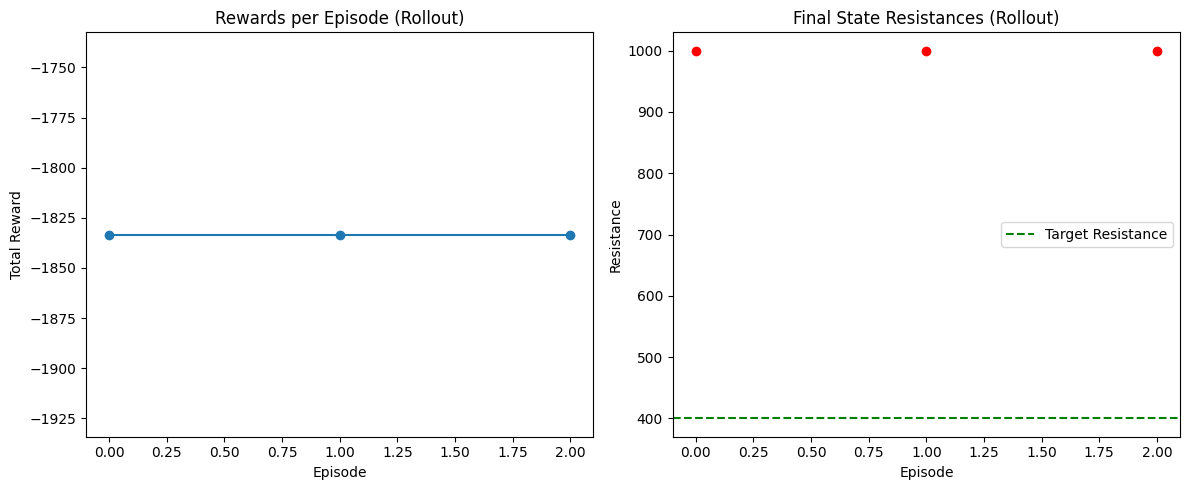

In [6]:
   

# Monte Carlo Agent
class MonteCarloAgent:
    def __init__(self, actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.actions = actions
        self.Q = {}
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def get_action(self, state, epsilon=None):
        '''e-greedy agent '''
        if epsilon is not None and np.random.rand() < epsilon: # np.radom.rand()를 활용하여 epsilon보다 작을 경우 랜덤 액션을 선택하도록 설정
            return np.random.choice(self.actions) # np.random.choice함수를 활용하여 액션 리스트 중에서 랜덤하게 선택
        else:
            Q_values = [self.Q.get((state, a), 0) for a in self.actions]
            return self.actions[np.argmax(Q_values)] # argmax를 활용하여 q함수가 max인 action을 return
    
    
    def update(self, episode):
        G = 0
        states_actions_rewards = []
        
        for state, action, reward in reversed(episode):
            G = self.gamma * G + reward # 현재의 reward에 할안된 보상 값을 더해줌
            states_actions_rewards.append((state, action, G))
        
        for state, action, G in reversed(states_actions_rewards):
            self.Q[(state, action)] = self.Q.get((state, action), 0) + self.alpha * (G - self.Q.get((state, action), 0))

    def get_q_table(self):
        """Q-테이블을 [state, action] 형태의 2D 배열로 반환"""
        if not self.Q:
            return np.zeros((len(self.state_lengths), len(self.actions)))

        max_state = max(state for state, _ in self.Q.keys())
        q_table = np.zeros((max_state + 1, len(self.actions)))

        for (state, action), q_value in self.Q.items():
            q_table[state, action-1] = q_value

        return q_table

    def show_q_table(self):
        """Q-테이블을 히트맵으로 시각화"""
        q_table = self.get_q_table().T

        plt.figure(figsize=(10, 6))
        plt.imshow(q_table, cmap='viridis', interpolation='nearest')
        plt.colorbar(label='Q-Value')

        # 상태(x축)와 행동(y축) 레이블 설정
        plt.xlabel('State')
        plt.ylabel('Action')
        plt.title('Q-Table Heatmap')

        # 각 셀에 Q-값 표시
        for i in range(q_table.shape[0]):
            for j in range(q_table.shape[1]):
                # plt.text(j, i, f"{q_table[i, j]:.2f}", ha='center', va='center', color='white' if q_table[i, j] > np.median(q_table) else 'black')
                plt.text(j, i, f"{q_table[i, j]:.2f}", ha='center', va='center', color='black')

        plt.show()
        

# 학습 함수 (num_episodes 인자 추가)
def train(env, agent, num_episodes=1000):
    for episode in range(num_episodes):
        state = env.reset()     # Episode시작마다 reset
        episode_data = []   # 

        while True:
            action = agent.get_action(state, epsilon=agent.epsilon)  # 학습 시 탐험 적용
            next_state, reward, done, _ = env.step(action)    # 
            episode_data.append((state, action, reward))     # 순서대로 결과 저장
            state = next_state                               # 다음 state로 이동

            if done:                                         # Done=True시 Episode 종료
                break

        agent.update(episode_data)                           # 저장된 데이터를 황용하여 보상 계산
        
        # 100 에피소드마다 진행 상황 출력
        if (episode + 1) % int(num_episodes/20) == 0:
            avg_reward = np.mean([r for _, _, r in episode_data])
            print(f"Episode {episode + 1}/{num_episodes} - Avg Reward: {avg_reward:.2f}")

# rollout 함수 (탐험 없음 + action 출력)
def rollout(env, agent, num_episodes=10, max_steps=7):
    rewards_history = []
    resistances = []

    for episode in range(num_episodes):
        print(f"\n=== Episode {episode + 1} ===")
        state = env.reset()
        episode_rewards = []
        episode_resistances = []

        for step in range(max_steps):
            action = agent.get_action(state, epsilon=0)  # rollout 시 탐험 없음
            next_state, reward, done, _ = env.step(action)

            state_length = env.state_lengths[state]
            state_resistance = state_length / action
            episode_resistances.append(state_resistance)

            episode_rewards.append(reward)

            # action 출력
            print(f"Step {step + 1}: State={state}, Action={action}, Resistance={state_resistance:.2f}")

            state = next_state

            if done:
                break

        total_reward = sum(episode_rewards)
        rewards_history.append(total_reward)
        resistances.append(episode_resistances[-1])

    return rewards_history, resistances

# 메인 실행 (num_episodes 인자 추가)
if __name__ == "__main__":
    env = Environment()
    agent = MonteCarloAgent(actions=[1, 2, 3, 4, 5], epsilon=0.1)

    # 학습 단계 (num_episodes 인자로 전달)
    train(env, agent, num_episodes=100000)

    # rollout 단계 (탐험 없음 + action 출력)
    rewards_history, resistances = rollout(env, agent, num_episodes=3, max_steps=7)

    # 결과 시각화
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rewards_history, marker='o')
    plt.title('Rewards per Episode (Rollout)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')

    plt.subplot(1, 2, 2)
    plt.scatter(range(len(resistances)), resistances, color='red')
    plt.axhline(y=env.target_resistance, color='g', linestyle='--', label='Target Resistance')
    plt.title('Final State Resistances (Rollout)')
    plt.xlabel('Episode')
    plt.ylabel('Resistance')
    plt.legend()

    plt.tight_layout()
    plt.show()

## 환경을 새롭게 정의 : 목표를 변경

1. 환경 설명 
     - episode당 steps 수 : 7 steps
     - state 이동 방법 : 1번부터 7번까지 순차적으로 움직임 
     - 7번까지 이동하면 episode 종료  
     - action_list = [1,2,3,4,5] 
     - num of actions = 5
     - state_line_length = [500, 550, 950, 1200, 2300, 3000, 5000]
     - target_resistance = 400
     - state_resistance = state_length/width, action을 width로 그대로 사용함     
     - 목표 : state_resistance 편차 최소화  
     - <font color="red"> reward : episode진행중에는 0, 마지막 step에서 만 resistance 편차를 구한 값을 return </font>        

In [7]:
# 환경 클래스
class Environment2(Environment):
    
    def reset(self):
        self.step_count = 0
        self.current_episode_resistances = []  # 매 에피소드 시작 시 초기화
        return self.step_count

    def step(self, action):
        state_length = self.state_lengths[self.step_count]
        state_resistance = state_length / action
        self.current_episode_resistances.append(state_resistance)  # 저항값 저장
        self.step_count += 1

        done = self.step_count >= len(self.state_lengths)

        # done 상태에서만 reward 계산 (에피소드 전체 저항값 편차 평균)
        if done:
            deviations = [abs(r - self.target_resistance) for r in self.current_episode_resistances]
            avg_deviation = np.mean(deviations)
            reward = 1000 / (avg_deviation + 1)  # 편차 평균에 반비례
            # reward = -np.std(self.current_episode_resistances)
            self.current_episode_resistances = []  # 다음 에피소드를 위해 초기화
        else:
            reward = 0  # 중간 스텝에서는 항상 0

        return self.step_count, reward, done, {}   

### 학습 실행

Episode 10000/200000 - Avg Reward: 0.51
Episode 20000/200000 - Avg Reward: 0.66
Episode 30000/200000 - Avg Reward: 0.86
Episode 40000/200000 - Avg Reward: 0.82
Episode 50000/200000 - Avg Reward: 0.58
Episode 60000/200000 - Avg Reward: 0.68
Episode 70000/200000 - Avg Reward: 0.69
Episode 80000/200000 - Avg Reward: 0.83
Episode 90000/200000 - Avg Reward: 0.84
Episode 100000/200000 - Avg Reward: 0.64
Episode 110000/200000 - Avg Reward: 0.84
Episode 120000/200000 - Avg Reward: 0.79
Episode 130000/200000 - Avg Reward: 0.47
Episode 140000/200000 - Avg Reward: 0.28
Episode 150000/200000 - Avg Reward: 0.72
Episode 160000/200000 - Avg Reward: 0.48
Episode 170000/200000 - Avg Reward: 0.65
Episode 180000/200000 - Avg Reward: 0.54
Episode 190000/200000 - Avg Reward: 0.69
Episode 200000/200000 - Avg Reward: 0.74


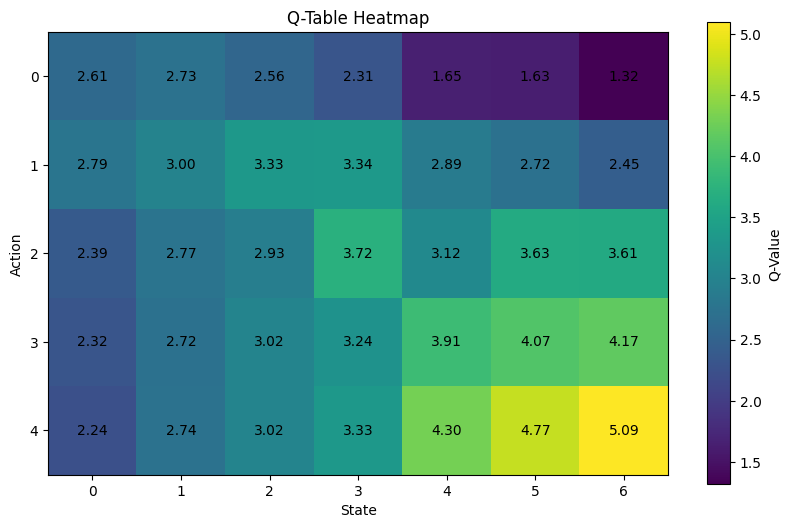


=== Episode 1 ===
Step 1: State=0, Action=2, Resistance=250.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=2, Resistance=475.00
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=1000.00

=== Episode 2 ===
Step 1: State=0, Action=2, Resistance=250.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=2, Resistance=475.00
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=1000.00

=== Episode 3 ===
Step 1: State=0, Action=2, Resistance=250.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=2, Resistance=475.00
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=100

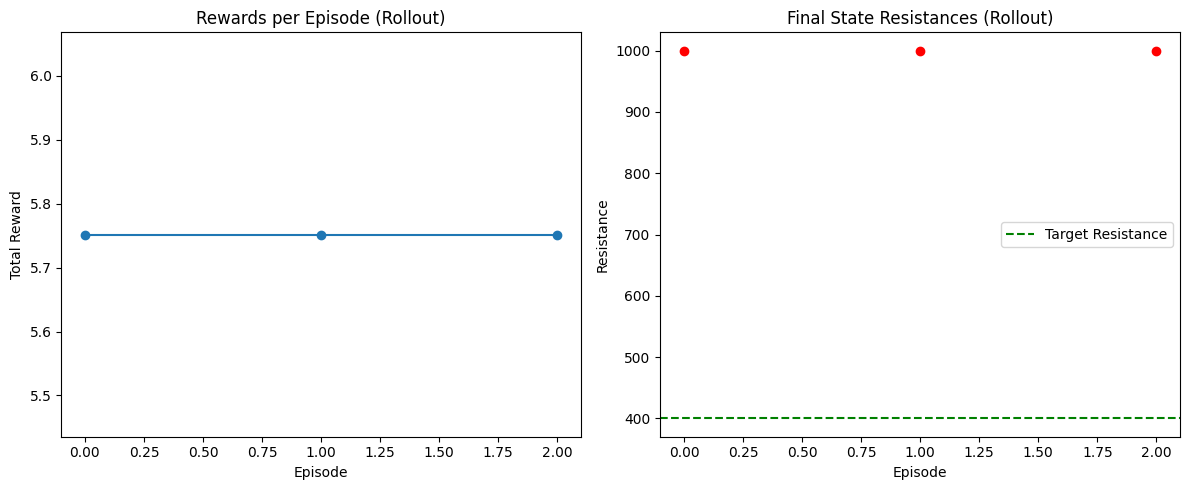

In [8]:
###
env = Environment2()
agent = MonteCarloAgent(actions=[1, 2, 3, 4, 5], epsilon=0.1)
train(env, agent, num_episodes=200000)

# Q-테이블 히트맵 출력
agent.show_q_table()

rewards_history, resistances = rollout(env, agent, num_episodes=3, max_steps=7)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rewards_history, marker='o')
plt.title('Rewards per Episode (Rollout)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.subplot(1, 2, 2)
plt.scatter(range(len(resistances)), resistances, color='red')
plt.axhline(y=env.target_resistance, color='g', linestyle='--', label='Target Resistance')
plt.title('Final State Resistances (Rollout)')
plt.xlabel('Episode')
plt.ylabel('Resistance')
plt.legend()
plt.tight_layout()
plt.show()

Episode 20000/200000 - Avg Reward: 0.30
Episode 40000/200000 - Avg Reward: 0.77
Episode 60000/200000 - Avg Reward: 0.61
Episode 80000/200000 - Avg Reward: 0.83
Episode 100000/200000 - Avg Reward: 0.86
Episode 120000/200000 - Avg Reward: 0.84
Episode 140000/200000 - Avg Reward: 0.72
Episode 160000/200000 - Avg Reward: 0.74
Episode 180000/200000 - Avg Reward: 0.73
Episode 200000/200000 - Avg Reward: 0.85


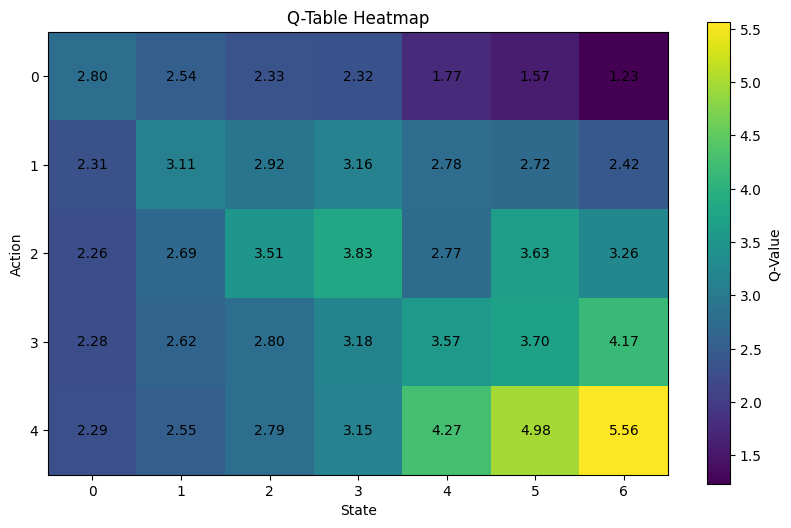


=== Episode 1 ===
Step 1: State=0, Action=1, Resistance=500.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=3, Resistance=316.67
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=1000.00

=== Episode 2 ===
Step 1: State=0, Action=1, Resistance=500.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=3, Resistance=316.67
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=1000.00

=== Episode 3 ===
Step 1: State=0, Action=1, Resistance=500.00
Step 2: State=1, Action=2, Resistance=275.00
Step 3: State=2, Action=3, Resistance=316.67
Step 4: State=3, Action=3, Resistance=400.00
Step 5: State=4, Action=5, Resistance=460.00
Step 6: State=5, Action=5, Resistance=600.00
Step 7: State=6, Action=5, Resistance=100

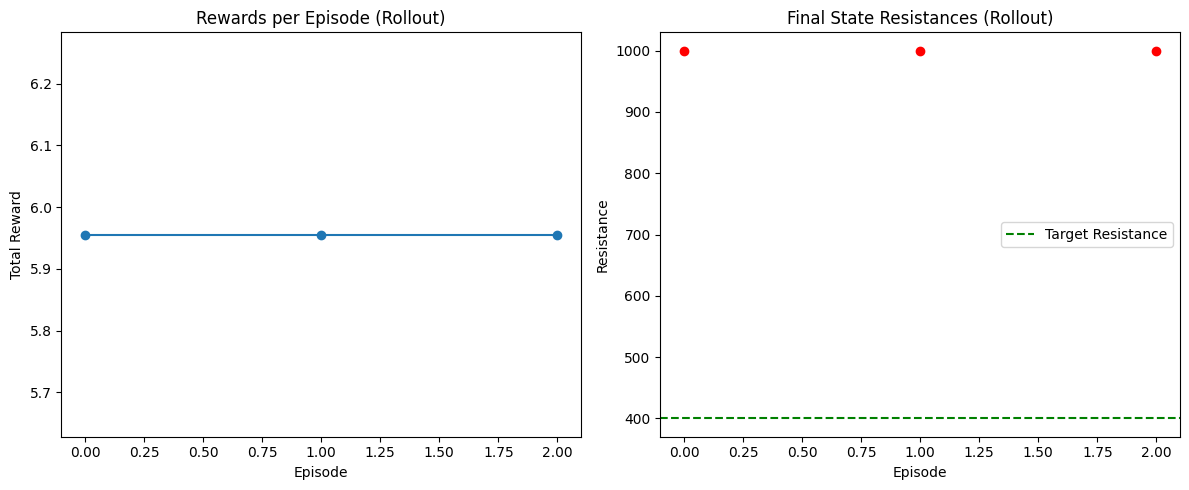

In [40]:
agent.get_q_table()

array([[2.19107472, 2.69561406, 2.1710707 , 2.14536634, 1.98328244],
       [2.47737499, 3.06377524, 2.33900072, 2.51257993, 2.35543938],
       [2.35527738, 3.32917786, 2.47177655, 2.63632271, 2.68322069],
       [2.32585733, 2.9692425 , 3.74846502, 3.03709961, 3.03658529],
       [1.7047681 , 2.64631663, 3.11558598, 3.30627773, 4.24588823],
       [1.5111179 , 2.86751808, 3.11868865, 3.57833103, 4.77884976],
       [1.29005776, 2.35506007, 3.25951101, 3.95919978, 5.11763344]])